# Per-Run Three Curves — SLP MNIST

For each run, a dedicated subplot shows **three curves**:

| Curve | Style | What it shows |
|-------|-------|---------------|
| Raw data | Thin line | Actual CE_Test values (connected) |
| Fitted curve | Solid colored line | `CE(x) = A + B / (x+1)^n` |
| Asymptote | Dashed line | `y = A` (converged CE floor) |

**Variables to change:** `PRUNING`, `BATCH_SIZE`, `N_RUNS`, `COLORMAP` in Cell 1.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmfit import Parameters, minimize
import warnings
warnings.filterwarnings("ignore")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  USER VARIABLES  ← change these
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PRUNING    = 0.0        # pruning fraction: 0.0, 0.1, ..., 0.8, 0.82, ..., 1.0
BATCH_SIZE = 64         # 64 | 1024 | 60000
N_RUNS     = 20         # how many runs to show (1-100)
COLORMAP   = "turbo"    # colormap for per-run colors
COLS       = 4          # subplots per row
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

BASE_DIR = r"C:\Users\Student\Desktop\Projects\research\physlab\SLP\SLP-MNIST\prune_layers_ALL"
OUT_DIR  = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.join(BASE_DIR, f"p-percentage_{PRUNING}", f"batch_size_{BATCH_SIZE}")

A_MIN, A_MAX = 0.1, 2.3
B_MIN, B_MAX = 0.0, 1000.0
N_MIN, N_MAX = 0.5, 3.0
LN10 = np.log(10)

assert os.path.isdir(DATA_DIR), f"Not found: {DATA_DIR}"
all_files = sorted(glob.glob(os.path.join(DATA_DIR, f"slp_{PRUNING}_{BATCH_SIZE}_run_*.txt")))
assert all_files, f"No run files in {DATA_DIR}"
files = all_files[:N_RUNS]

print(f"Pruning  : {PRUNING*100:.1f}%")
print(f"Batch    : {BATCH_SIZE}")
print(f"Runs     : {len(files)} (of {len(all_files)} available)")

Pruning  : 0.0%
Batch    : 64
Runs     : 20 (of 100 available)


In [2]:
# ── Fitting helpers ───────────────────────────────────────────────────────────

def initialize_guesses(x, y):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    A0 = np.percentile(y, 5)
    B0 = np.percentile(y, 95) - A0
    n0 = 0.5
    if len(x) > 10:
        denom = y[0] - A0
        if abs(denom) > 1e-10:
            frac = max(1e-6, (y[0] - y[-1]) / denom)
            if frac > 0:
                n0 = max(0.3, min(1.5, -np.log(frac)))
    return A0, n0, B0

def _model(params, x):
    v = params.valuesdict()
    return v['A'] + v['B'] / ((x + 1) ** v['n'])

def _residual(params, x, data):
    return x * (_model(params, x) - data)

def fit_run(x, y):
    mask = ~np.isnan(y)
    x, y = x[mask], y[mask]
    if len(x) < 10:
        return None
    A0, n0, B0 = initialize_guesses(x, y)
    params = Parameters()
    params.add('A', value=A0, min=A_MIN, max=A_MAX)
    params.add('B', value=B0, min=B_MIN, max=B_MAX)
    params.add('n', value=n0, min=N_MIN, max=N_MAX)
    try:
        result = minimize(_residual, params, args=(x, y))
        v = result.params.valuesdict()
        return v['A'], v['B'], v['n']
    except Exception:
        return None


# ── Load & fit ────────────────────────────────────────────────────────────────
raw_data   = []
fit_params = []
skipped    = []

for fpath in files:
    run_id = os.path.basename(fpath)
    try:
        df = pd.read_csv(fpath, sep=r"\s+")
        df.columns = df.columns.str.strip()
        df["CE_TEST"]      = pd.to_numeric(df["CE_TEST"],      errors="coerce")
        df["Batch_Number"] = pd.to_numeric(df["Batch_Number"], errors="coerce")
        df = df.dropna(subset=["CE_TEST", "Batch_Number"])
        if len(df) < 5:
            skipped.append((run_id, "too few rows"))
            continue
    except Exception as e:
        skipped.append((run_id, str(e)))
        continue

    x = df["Batch_Number"].values
    y = df["CE_TEST"].values
    result = fit_run(x, y)
    if result is None:
        skipped.append((run_id, "fit did not converge"))
        continue

    A, B, n = result
    raw_df = df[["Batch_Number", "CE_TEST"]].copy()
    raw_df["run_id"] = run_id
    raw_data.append(raw_df)
    fit_params.append({"run_id": run_id, "A": A, "B": B, "n": n})

params_df = pd.DataFrame(fit_params)
n_ok = len(fit_params)
print(f"Fitted: {n_ok} / {len(files)} runs")
if skipped:
    for name, reason in skipped:
        print(f"  SKIP {name}: {reason}")

Fitted: 20 / 20 runs


Saved: C:\Users\Student\Desktop\Projects\research\physlab\SLP\SLP-MNIST\TEST_FITTING\per_run_curves_p0.0_bs64_n20.png


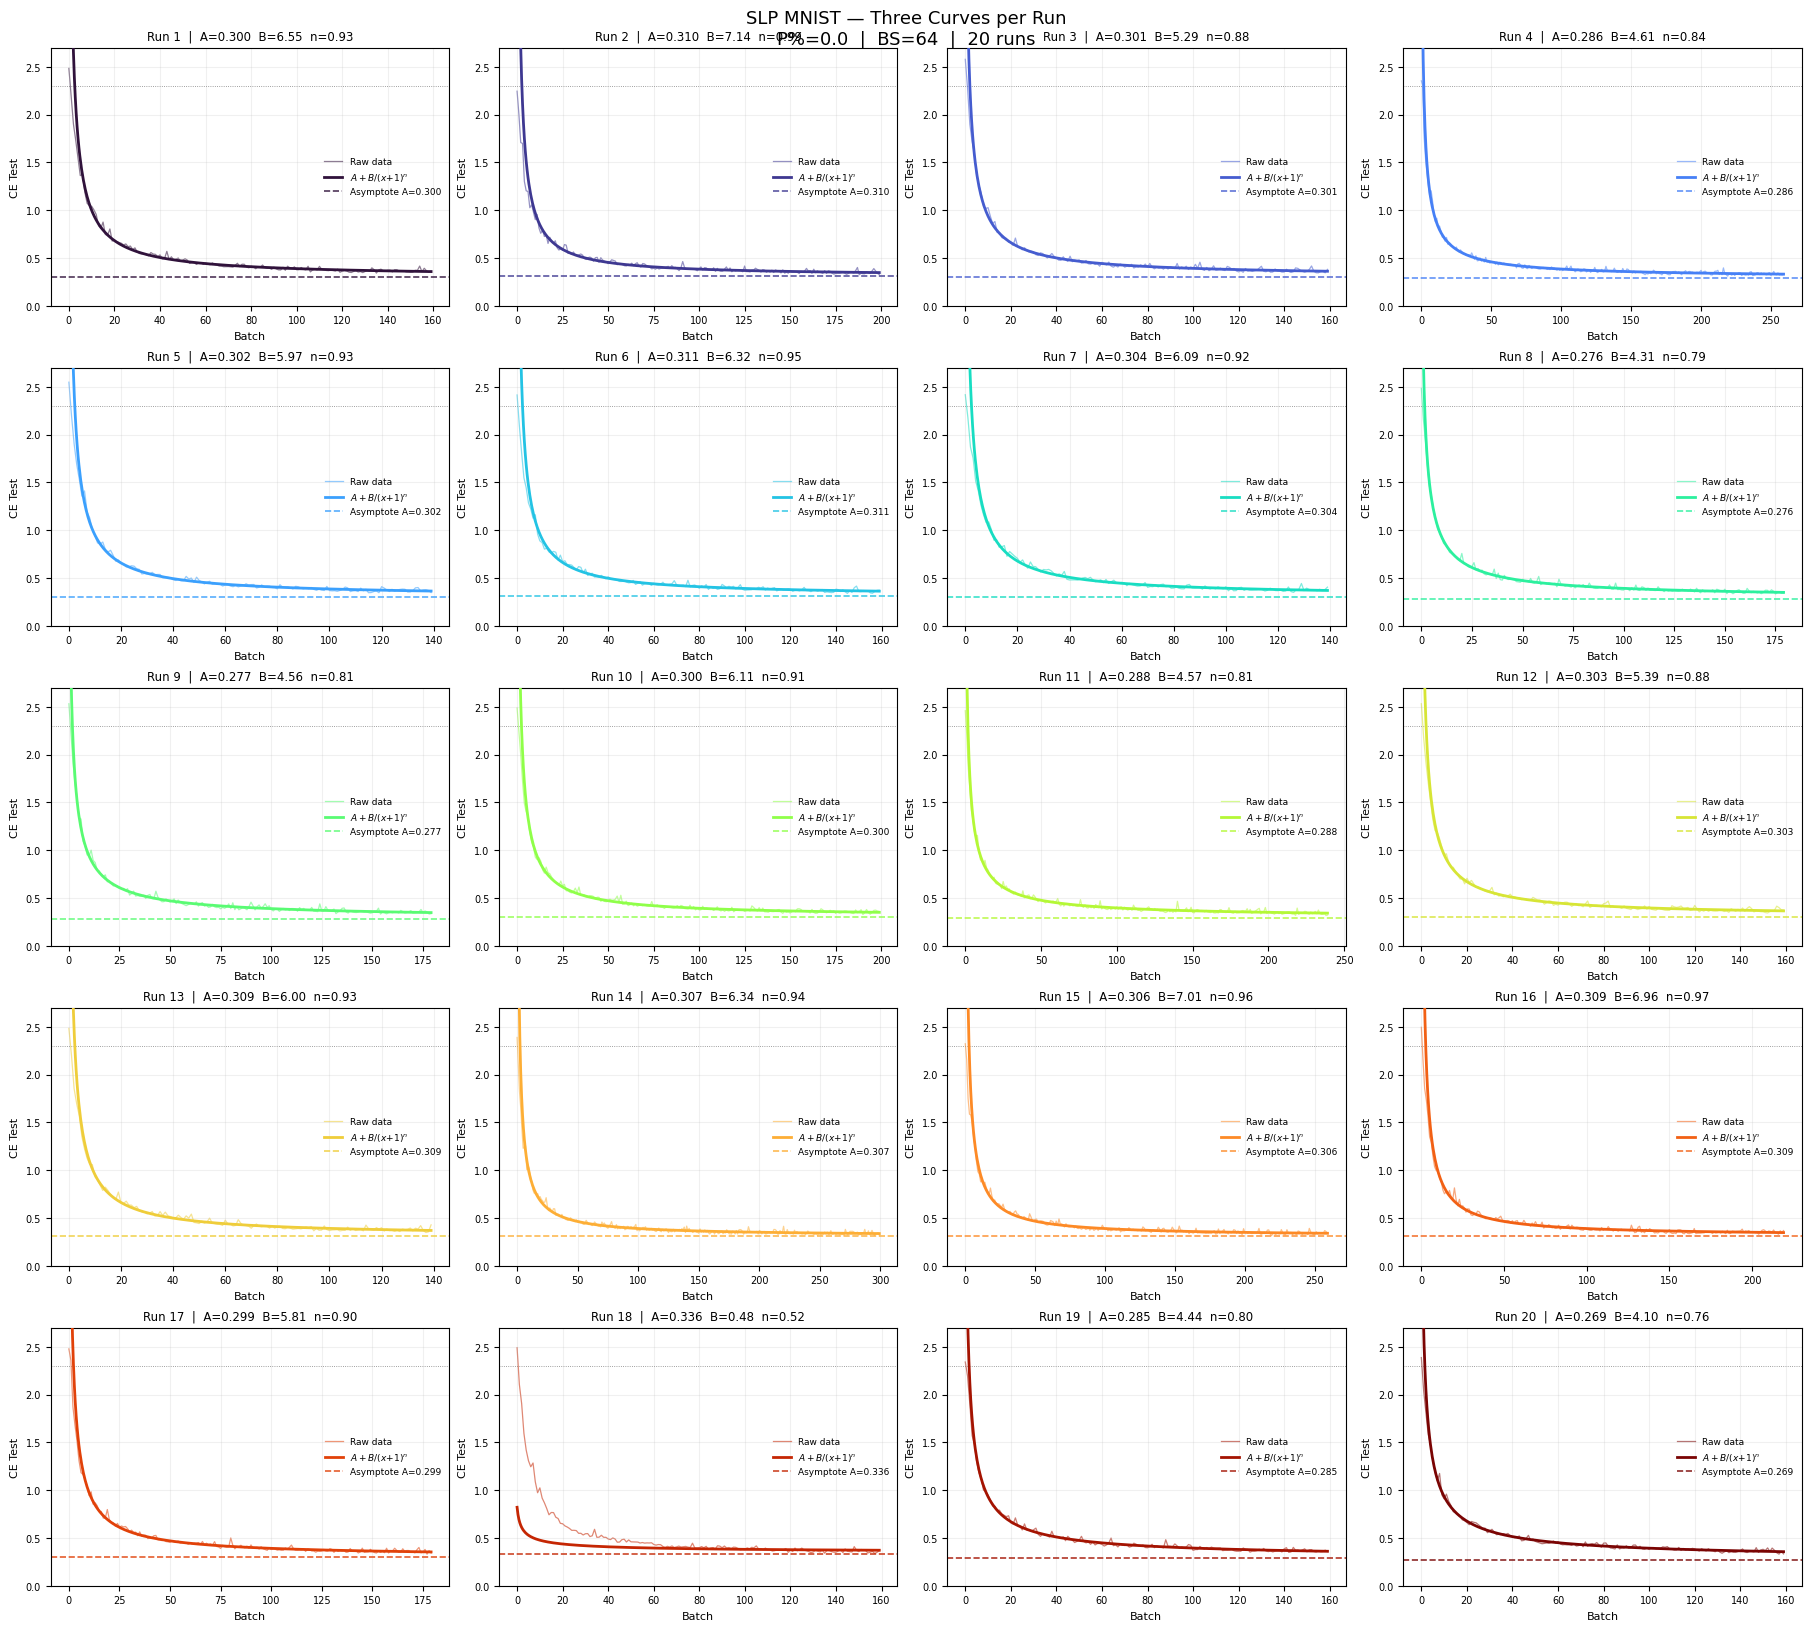

In [3]:
# ── Per-run subplot grid — three curves per panel ─────────────────────────────

cmap       = plt.get_cmap(COLORMAP)
run_colors = [cmap(i / max(n_ok - 1, 1)) for i in range(n_ok)]

rows = int(np.ceil(n_ok / COLS))
fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 4.5, rows * 3.2),
                          constrained_layout=True)
axes = np.array(axes).flatten()

for i, (d, p_row) in enumerate(zip(raw_data, params_df.itertuples())):
    ax  = axes[i]
    c   = run_colors[i]
    x   = d["Batch_Number"].values
    y   = d["CE_TEST"].values
    A, B, n_exp = p_row.A, p_row.B, p_row.n

    x_fit = np.linspace(x[0], x[-1], 400)
    y_fit = A + B / ((x_fit + 1) ** n_exp)

    # Curve 1 — raw data (thin line)
    ax.plot(x, y, color=c, linewidth=0.9, alpha=0.55, zorder=1, label="Raw data")

    # Curve 2 — fitted CE(x) = A + B/(x+1)^n
    ax.plot(x_fit, y_fit, color=c, linewidth=2.0, alpha=1.0, zorder=3,
            label=r"$A + B/(x{+}1)^n$")

    # Curve 3 — asymptote y = A
    ax.axhline(A, color=c, linewidth=1.2, linestyle="--", alpha=0.85, zorder=2,
               label=f"Asymptote A={A:.3f}")

    ax.set_ylim(0, 2.7)
    ax.set_title(f"Run {i+1}  |  A={A:.3f}  B={B:.2f}  n={n_exp:.2f}",
                 fontsize=8.5)
    ax.set_xlabel("Batch", fontsize=8)
    ax.set_ylabel("CE Test", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6.5, frameon=False)
    ax.grid(True, alpha=0.18)

    # ln(10) reference
    ax.axhline(LN10, color="gray", linewidth=0.6, linestyle=":", zorder=0)

# hide unused axes
for j in range(n_ok, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"SLP MNIST — Three Curves per Run\n"
    f"P%={PRUNING*100:.1f}  |  BS={BATCH_SIZE}  |  {n_ok} runs",
    fontsize=13, y=1.01
)

fig_name = f"per_run_curves_p{PRUNING}_bs{BATCH_SIZE}_n{n_ok}.png"
fig_path = os.path.join(OUT_DIR, fig_name)
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()